# Global Wheat Head: Domain-wise Score Analysis

This notebook checks whether hard domains have higher difficulty scores than easy domains.

Inputs:
- `score_path`: score JSON from Step 3 scoring output
- `raw_data_path`: raw dataset organized by domain folders
- `yolo_data_path`: YOLO dataset used for scoring

Main outputs:
- per-domain score statistics
- domain ranking (easy -> hard)
- statistical test comparing hard vs easy domain groups

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

score_path = "/home/khanh/Projects/DifficultyAgri/.cache_result/global_wheat_head/scoring_result/seed_123/score_results.json"
raw_data_path = "/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw"
yolo_data_path = "/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format/global_wheat_head_yolo"

for p in [score_path, raw_data_path, yolo_data_path]:
    print(f"Exists: {os.path.exists(p)} | {p}")

Exists: True | /home/khanh/Projects/DifficultyAgri/.cache_result/global_wheat_head/scoring_result/seed_123/score_results.json
Exists: True | /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw
Exists: True | /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format/global_wheat_head_yolo


## Build Image-to-Domain Mapping

Raw data is organized by domains (e.g., `arvalis_1`, `ethz_1`, ...). We map each image basename to its domain so each scored YOLO image can be linked back to domain.

In [2]:
def build_image_to_domain_map(raw_root: str) -> pd.DataFrame:
    domain_dirs = [p for p in sorted(Path(raw_root).iterdir()) if p.is_dir() and not p.name.startswith("labels")]

    rows = []
    for domain_dir in domain_dirs:
        domain_name = domain_dir.name
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            for img_path in domain_dir.glob(ext):
                rows.append(
                    {
                        "image_name": img_path.name,
                        "image_stem": img_path.stem,
                        "domain": domain_name,
                        "raw_path": str(img_path),
                    }
                )

    mapping_df = pd.DataFrame(rows).drop_duplicates(subset=["image_name"])
    return mapping_df

mapping_df = build_image_to_domain_map(raw_data_path)
print(f"Mapped raw images: {len(mapping_df):,}")
print(f"Domains found: {mapping_df['domain'].nunique()}")
print(sorted(mapping_df['domain'].unique()))
mapping_df.head()

Mapped raw images: 4,698
Domains found: 11
['arvalis_1', 'arvalis_2', 'arvalis_3', 'ethz_1', 'inrae_1', 'nau_1', 'rres_1', 'uq_1', 'usask_1', 'utokyo_1', 'utokyo_2']


,image_name,image_stem,domain,raw_path
0,818ed471-6ab5-4da6-8da0-ad70d1893338.png,818ed471-6ab5-4da6-8da0-ad70d1893338,arvalis_1,/home/khanh/Projects/DifficultyAgri/datasets/g...
1,2e52ec72-26ec-4e61-b12a-1792a0853153.png,2e52ec72-26ec-4e61-b12a-1792a0853153,arvalis_1,/home/khanh/Projects/DifficultyAgri/datasets/g...
2,6564a4e5-9fab-4238-b53e-092b29d8db61.png,6564a4e5-9fab-4238-b53e-092b29d8db61,arvalis_1,/home/khanh/Projects/DifficultyAgri/datasets/g...
3,57555d4c-83d0-4cf4-a5da-29ca3fff6cf1.png,57555d4c-83d0-4cf4-a5da-29ca3fff6cf1,arvalis_1,/home/khanh/Projects/DifficultyAgri/datasets/g...
4,25b5a2c6-3ad2-4e68-89fd-e63edd734db0.png,25b5a2c6-3ad2-4e68-89fd-e63edd734db0,arvalis_1,/home/khanh/Projects/DifficultyAgri/datasets/g...


## Load Score Results and Join with Domains

We use `image_difficulties` from the score JSON and map each scored image to its domain via image filename.

In [3]:
with open(score_path, "r") as f:
    score_data = json.load(f)

image_difficulties = score_data.get("image_difficulties", [])
print(f"Scored images in JSON: {len(image_difficulties):,}")

score_rows = []
for item in image_difficulties:
    image_path = item.get("image_path")
    image_name = Path(image_path).name if image_path else None
    split = None
    if image_path:
        parts = Path(image_path).parts
        if "train" in parts:
            split = "train"
        elif "val" in parts:
            split = "val"
        elif "test" in parts:
            split = "test"

    score_rows.append(
        {
            "image_path": image_path,
            "image_name": image_name,
            "split": split,
            "difficulty_score": item.get("difficulty_score"),
            "num_objects": item.get("num_objects"),
            "false_positive_rate": item.get("false_positive_rate"),
            "missed_detections_rate": item.get("missed_detections_rate"),
        }
    )

score_df = pd.DataFrame(score_rows)
merged_df = score_df.merge(mapping_df[["image_name", "domain"]], on="image_name", how="left")

missing_domain = merged_df["domain"].isna().sum()
print(f"Rows in merged df: {len(merged_df):,}")
print(f"Rows missing domain mapping: {missing_domain:,}")
print(f"Mapped ratio: {(1 - missing_domain / max(len(merged_df), 1)) * 100:.2f}%")

merged_df.head()

Scored images in JSON: 2,700
Rows in merged df: 2,700
Rows missing domain mapping: 0
Mapped ratio: 100.00%


,image_path,image_name,split,difficulty_score,num_objects,false_positive_rate,missed_detections_rate,domain
0,/home/khanh/Projects/DifficultyAgri/datasets/g...,001678dc-afb4-4e28-af42-d93c2c91f2f6.png,train,0.341177,70,0.086957,0.10000,ethz_1
1,/home/khanh/Projects/DifficultyAgri/datasets/g...,004066a1-824d-4459-bb05-abaa09224bd6.png,train,0.298675,25,0.076923,0.04000,inrae_1
2,/home/khanh/Projects/DifficultyAgri/datasets/g...,00ac2038-7a5b-46d8-9063-73d11a186355.png,train,0.307189,30,0.068966,0.10000,arvalis_3
3,/home/khanh/Projects/DifficultyAgri/datasets/g...,00ac89bb-a4e6-444a-92e5-4ec5243de209.png,train,0.390822,47,0.120000,0.06383,arvalis_1
4,/home/khanh/Projects/DifficultyAgri/datasets/g...,00e049a1-2dff-433e-8052-1a9fd0b8d466.png,train,0.237274,43,0.104167,0.00000,rres_1


## Domain-Level Score Statistics

Compute per-domain score summary and rank domains from easiest to hardest by mean difficulty score.

Domain ranking by mean difficulty score (easy -> hard):


,domain,n_images,mean_score,median_score,std_score,q25,q75,rank_easy_to_hard
0,rres_1,363,0.259605,0.254767,0.047248,0.228622,0.284016,1
1,inrae_1,146,0.283531,0.274700,0.062024,0.241221,0.313360,2
2,ethz_1,592,0.291101,0.287731,0.043670,0.261370,0.315289,3
3,arvalis_3,457,0.347400,0.328876,0.087949,0.286627,0.385909,4
4,arvalis_1,827,0.369111,0.355218,0.086042,0.315777,0.397679,5
5,usask_1,153,0.383764,0.368690,0.088052,0.326138,0.427272,6
6,arvalis_2,162,0.430590,0.424365,0.084883,0.360137,0.476980,7


/tmp/ipykernel_940668/1546353227.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=domain_stats, x="domain", y="mean_score", palette="viridis", ax=ax)


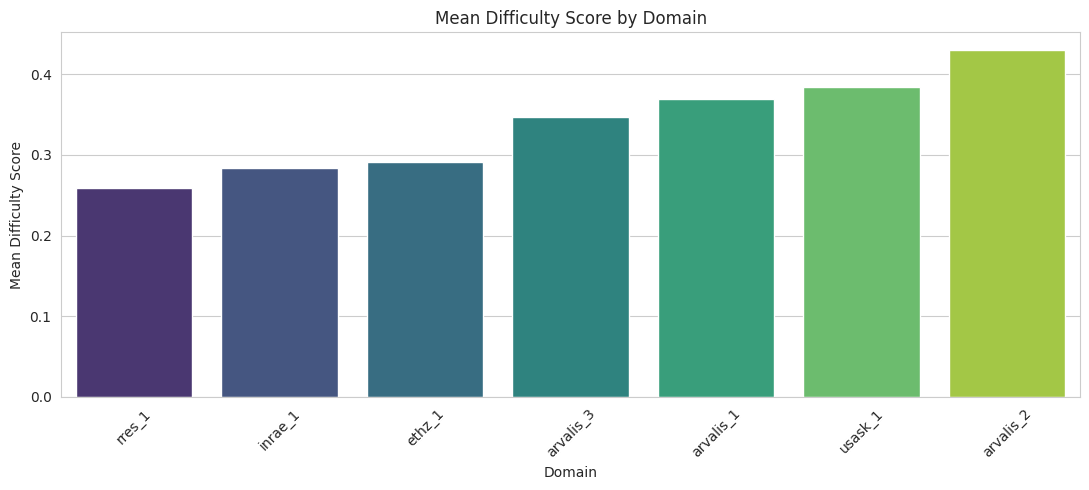

Domain Difficulty Ranking:
1. rres_1 - Mean Score: 0.2596 (n=363)
2. inrae_1 - Mean Score: 0.2835 (n=146)
3. ethz_1 - Mean Score: 0.2911 (n=592)
4. arvalis_3 - Mean Score: 0.3474 (n=457)
5. arvalis_1 - Mean Score: 0.3691 (n=827)
6. usask_1 - Mean Score: 0.3838 (n=153)
7. arvalis_2 - Mean Score: 0.4306 (n=162)


In [7]:
domain_stats = (
    merged_df.dropna(subset=["domain", "difficulty_score"])
    .groupby("domain", as_index=False)
    .agg(
        n_images=("difficulty_score", "size"),
        mean_score=("difficulty_score", "mean"),
        median_score=("difficulty_score", "median"),
        std_score=("difficulty_score", "std"),
        q25=("difficulty_score", lambda s: s.quantile(0.25)),
        q75=("difficulty_score", lambda s: s.quantile(0.75)),
    )
    .sort_values("mean_score", ascending=True)
    .reset_index(drop=True)
)


domain_stats["rank_easy_to_hard"] = np.arange(1, len(domain_stats) + 1)

print("Domain ranking by mean difficulty score (easy -> hard):")
display(domain_stats)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=domain_stats, x="domain", y="mean_score", palette="viridis", ax=ax)
ax.set_title("Mean Difficulty Score by Domain")
ax.set_xlabel("Domain")
ax.set_ylabel("Mean Difficulty Score")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Print the results in a more readable format
print("Domain Difficulty Ranking:")
for idx, row in domain_stats.iterrows():
    print(f"{row['rank_easy_to_hard']}. {row['domain']} - Mean Score: {row['mean_score']:.4f} (n={row['n_images']})")
    

## Hard vs Easy Domain Comparison

Define hard/easy domains from domain mean score ranking.

Default rule:
- easy domains: bottom 30% by mean score
- hard domains: top 30% by mean score

Then compare image-level score distributions with Mann-Whitney U test.

Total domains: 7
Easy domains (2): ['rres_1', 'inrae_1']
Hard domains (2): ['usask_1', 'arvalis_2']
Image counts -> easy: 509, hard: 315


,group,n_images,mean_score,median_score
0,easy,509,0.266468,0.259739
1,hard,315,0.407846,0.390156


Mann-Whitney U test (alternative='hard > easy')
U statistic: 150240.000
p-value: 0.000000
Conclusion: hard domains have significantly higher scores than easy domains (p < 0.05).


/tmp/ipykernel_940668/1240167327.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


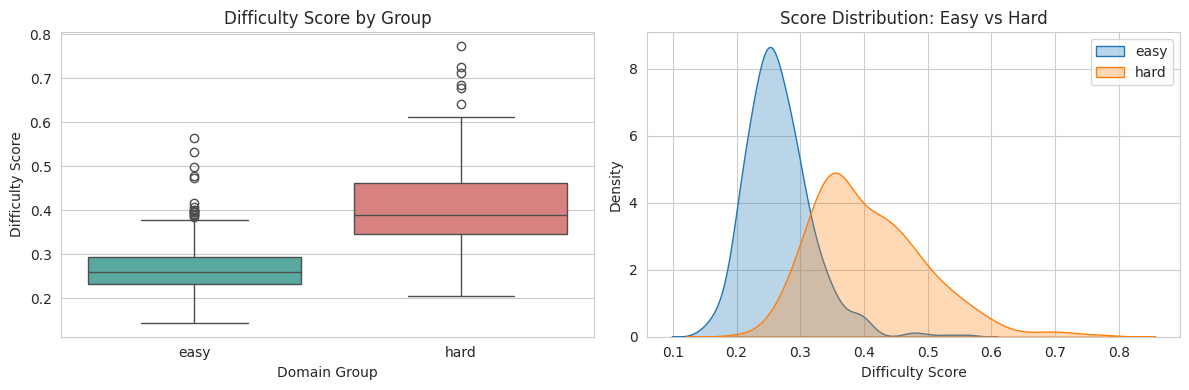

In [5]:
group_frac = 0.30
n_domains = len(domain_stats)
n_group = max(1, int(np.floor(n_domains * group_frac)))

easy_domains = domain_stats.head(n_group)["domain"].tolist()
hard_domains = domain_stats.tail(n_group)["domain"].tolist()

analysis_df = merged_df.dropna(subset=["domain", "difficulty_score"]).copy()
analysis_df["domain_group"] = "middle"
analysis_df.loc[analysis_df["domain"].isin(easy_domains), "domain_group"] = "easy"
analysis_df.loc[analysis_df["domain"].isin(hard_domains), "domain_group"] = "hard"

easy_scores = analysis_df.loc[analysis_df["domain_group"] == "easy", "difficulty_score"].values
hard_scores = analysis_df.loc[analysis_df["domain_group"] == "hard", "difficulty_score"].values

print(f"Total domains: {n_domains}")
print(f"Easy domains ({len(easy_domains)}): {easy_domains}")
print(f"Hard domains ({len(hard_domains)}): {hard_domains}")
print(f"Image counts -> easy: {len(easy_scores):,}, hard: {len(hard_scores):,}")

mean_easy = float(np.mean(easy_scores)) if len(easy_scores) else np.nan
mean_hard = float(np.mean(hard_scores)) if len(hard_scores) else np.nan
median_easy = float(np.median(easy_scores)) if len(easy_scores) else np.nan
median_hard = float(np.median(hard_scores)) if len(hard_scores) else np.nan

if len(easy_scores) > 0 and len(hard_scores) > 0:
    u_stat, p_value = mannwhitneyu(hard_scores, easy_scores, alternative="greater")
else:
    u_stat, p_value = np.nan, np.nan

result_table = pd.DataFrame(
    {
        "group": ["easy", "hard"],
        "n_images": [len(easy_scores), len(hard_scores)],
        "mean_score": [mean_easy, mean_hard],
        "median_score": [median_easy, median_hard],
    }
)

display(result_table)

print("Mann-Whitney U test (alternative='hard > easy')")
print(f"U statistic: {u_stat:.3f}")
print(f"p-value: {p_value:.6f}")

if np.isfinite(p_value):
    if p_value < 0.05:
        print("Conclusion: hard domains have significantly higher scores than easy domains (p < 0.05).")
    else:
        print("Conclusion: not enough evidence that hard domains have higher scores than easy domains (p >= 0.05).")
else:
    print("Conclusion: test could not be computed due to missing samples.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(
    data=analysis_df[analysis_df["domain_group"].isin(["easy", "hard"])],
    x="domain_group",
    y="difficulty_score",
    order=["easy", "hard"],
    palette={"easy": "#4DB6AC", "hard": "#E57373"},
    ax=axes[0],
)
axes[0].set_title("Difficulty Score by Group")
axes[0].set_xlabel("Domain Group")
axes[0].set_ylabel("Difficulty Score")

sns.kdeplot(easy_scores, label="easy", fill=True, alpha=0.3, ax=axes[1])
sns.kdeplot(hard_scores, label="hard", fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title("Score Distribution: Easy vs Hard")
axes[1].set_xlabel("Difficulty Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Split-Aware Domain Check (Optional)

This table helps verify the domain effect is not only from one split (train/val/test).

In [6]:
split_domain_stats = (
    merged_df.dropna(subset=["domain", "difficulty_score"])
    .groupby(["split", "domain"], as_index=False)
    .agg(n_images=("difficulty_score", "size"), mean_score=("difficulty_score", "mean"))
    .sort_values(["split", "mean_score"], ascending=[True, True])
)

display(split_domain_stats)

pivot = split_domain_stats.pivot(index="domain", columns="split", values="mean_score")
print("Mean score by domain x split:")
display(pivot)

,split,domain,n_images,mean_score
5,train,rres_1,363,0.259605
4,train,inrae_1,146,0.283531
3,train,ethz_1,592,0.291101
2,train,arvalis_3,457,0.347400
0,train,arvalis_1,827,0.369111
6,train,usask_1,153,0.383764
1,train,arvalis_2,162,0.430590


Mean score by domain x split:


split,train
domain,
arvalis_1,0.369111
arvalis_2,0.430590
arvalis_3,0.347400
ethz_1,0.291101
inrae_1,0.283531
rres_1,0.259605
usask_1,0.383764
